project: Cats&Dogs classification using cnn

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os
import random


#Invoking libraries
#Tensorflow: to build &training the model
#matplotlib:Display images and graphs



In [6]:
print(tf.__version__)

2.19.0


In [51]:
dataset_path = "Photos"
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(100, 100),
    batch_size=2,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(100, 100),
    batch_size=2,
    validation_split=0.2,
    subset="validation",
    seed=123
)



Found 9 files belonging to 2 classes.
Using 8 files for training.
Found 9 files belonging to 2 classes.
Using 1 files for validation.


In [ ]:
#image_dataset_from_directory:to dawnload the photos from folder called "photos"
#cache() to speed up data reading.
#shuffle() is used to shuffle the training data.
#prefetch() is used to load data batches in advance and increase training speed


In [7]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(8).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [53]:
model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()




Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,609 (4.15 MB)

 Trainable params: 1,088,609 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Rescaling: Convert values from [0, 255] to [0, 1].
#Conv2D + MaxPooling*: To extract features and reduce dimensions.
#Flatten + Dense*: To transform features and make a decision.
#Dropout: To prevent overfitting.
#Sigmoid: Outputs a value between 0 and 1 for binary classification (cat or dog).

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_ds, validation_data=val_ds, epochs=5)



Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.5000 - loss: 0.7895 - val_accuracy: 1.0000 - val_loss: 0.1669
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9167 - loss: 0.3397 - val_accuracy: 1.0000 - val_loss: 0.0590
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2667 - loss: 2.3360 - val_accuracy: 1.0000 - val_loss: 0.5172
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9167 - loss: 0.2552 - val_accuracy: 0.0000e+00 - val_loss: 0.8064
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6333 - loss: 0.4622 - val_accuracy: 0.0000e+00 - val_loss: 0.9917


In [ ]:
#Model Compilation and Training:
#Adam the optimizer to update the model’s weights efficiently.
#binary_crossentropy as the loss function because this is a binary classification problem (cat or dog).
#The model is trained for 5 epochs.

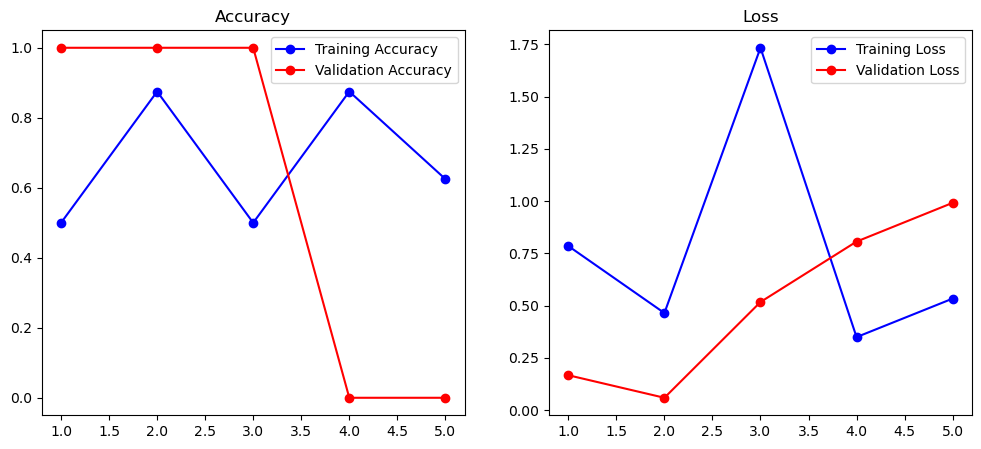

In [55]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title("Loss")
plt.legend()
plt.show()


In [61]:
model.save("cat_dog_model.keras")


In [63]:
from tensorflow.keras.models import load_model
model = load_model("cat_dog_model.keras")



In [73]:
def random_predict():
    folder = "Photos"
    categories = ["Cats", "Dogs"]
    actual_class = random.choice(categories)
    path = os.path.join(folder, actual_class)
    images = os.listdir(path)
    if not images:
        print(f"No images found in {path}")
        return
    img_name = random.choice(images)
    img_path = os.path.join(path, img_name)

    img = load_img(img_path, target_size=(100, 100))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)

    pred = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis("off")
    if pred > 0.5:
        label = f"Dog ({pred*100:.2f}%)"
    else:
        label = f"Cat ({(1 - pred)*100:.2f}%)"

    plt.title(f"{label}\n(True: {actual_class})")
    plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


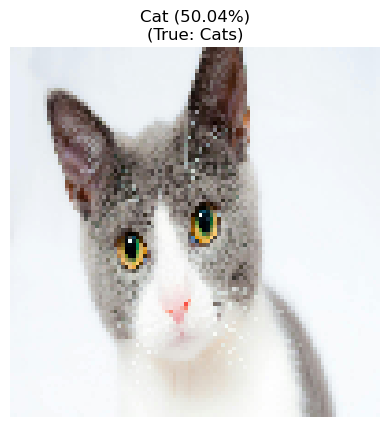

In [75]:
random_predict()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


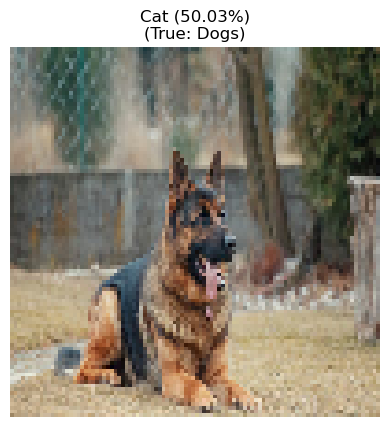

In [77]:
random_predict()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


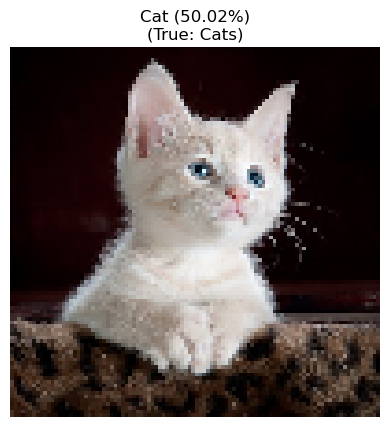

In [95]:
random_predict()


In [83]:
model.save("my_cat_dog_model.keras")


In [85]:
from tensorflow.keras.models import load_model
model = load_model("my_cat_dog_model.keras")


In [87]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
def predict_on_image(image_path):
    img = load_img(image_path, target_size=(100, 100))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0) 
    pred = model.predict(img_array)[0][0]
    plt.imshow(img)
    plt.axis("off")
    if pred > 0.5:
        label = f"Dog ({pred*100:.2f}%)"
    else:
        label = f"Cat ({(1 - pred)*100:.2f}%)"

    plt.title(label)
    plt.show()


In [97]:
def random_predict():
    folder = "Photos"
    categories = ["Cats", "Dogs"]
    actual_class = random.choice(categories)
    path = os.path.join(folder, actual_class)
    images = [img for img in os.listdir(path) if not img.startswith('.')]
    if not images:
        print(f"No images found in {path}")
        return
    img_name = random.choice(images)
    img_path = os.path.join(path, img_name)
    img = load_img(img_path, target_size=(100, 100))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)
    pred = model.predict(img_array)[0][0]
    plt.imshow(img)
    plt.axis("off")
    if pred > 0.5:
        label = f"Dog ({pred*100:.2f}%)"
    else:
        label = f"Cat ({(1 - pred)*100:.2f}%)"
    plt.title(f"{label}\n(True: {actual_class})")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


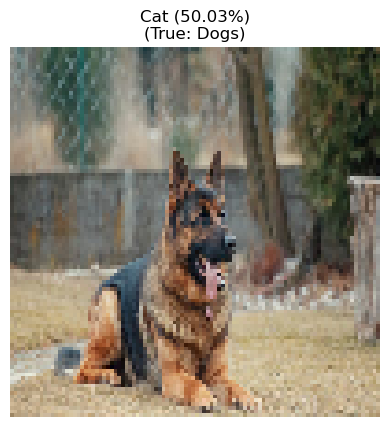

In [99]:
random_predict()


In [105]:
model.save("my_cat_dog_model.keras")
print("Model saved successfully")


Model saved successfully


In [43]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os
import random
model = load_model("my_cat_dog_model.keras")
print("Model loaded successfully")
def predict_on_image(image_path):
    img = load_img(image_path, target_size=(100, 100))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)
    pred = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis("off")
    label = "Dog" if pred > 0.5 else "Cat"
    confidence = pred if pred > 0.5 else 1 - pred
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.show()
 #predict_on_image("Photos/Cats/cat1.jpg")#

Model loaded successfully


In [45]:
#def random_predict():
    folder = "Photos"
    categories = ["Cats", "Dogs"]
    actual_class = random.choice(categories)
    path = os.path.join(folder, actual_class)
    images = [img for img in os.listdir(path) if not img.startswith('.')]
    if not images:
        print(f"No images found in {path}")
        return
    img_name = random.choice(images)
    img_path = os.path.join(path, img_name)
    img = load_img(img_path, target_size=(100, 100))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)
    pred = model.predict(img_array)[0][0]
    plt.imshow(img)
    plt.axis("off")
    if pred > 0.5:
        label = f"Dog ({pred*100:.2f}%)"
    else:
        label = f"Cat ({(1 - pred)*100:.2f}%)"
    plt.title(f"{label}\n(True: {actual_class})")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


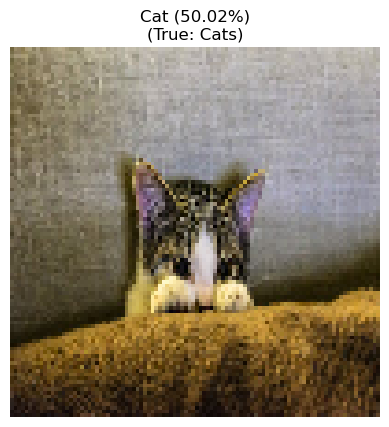

In [47]:
#random_predict()